# Loan Approval Prediction

The objective of this project is to predict whether a loan application will be approved or rejected based on applicant details such as income, education, credit history, and property area.

This helps financial institutions automate the loan approval process and reduce manual effort.

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(614, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object

/tmp/ipykernel_1373/303001128.py:30: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)
/tmp/ipykernel_1373/303001128.py:32: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try u

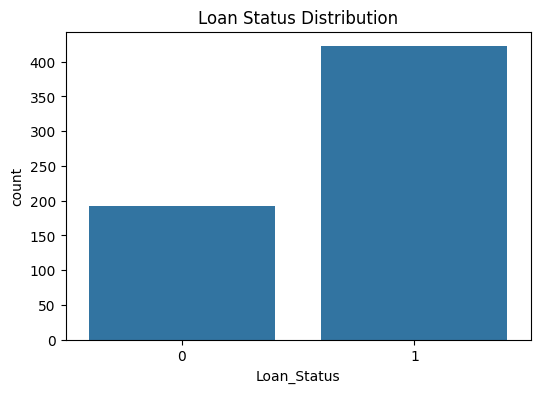

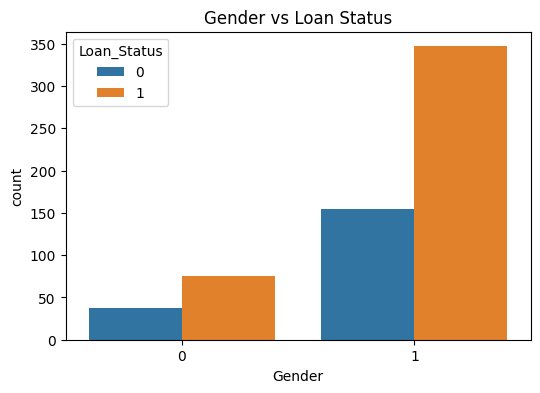

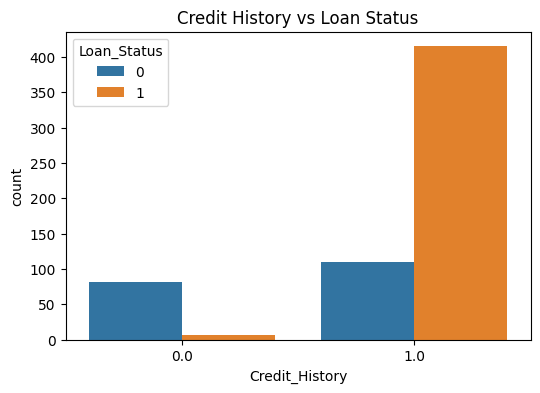

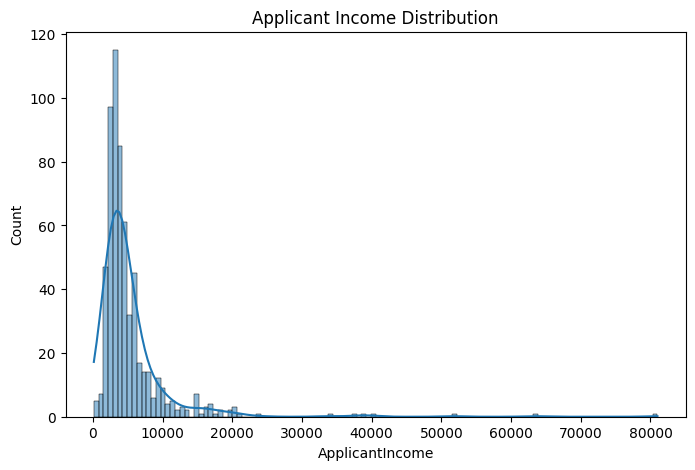

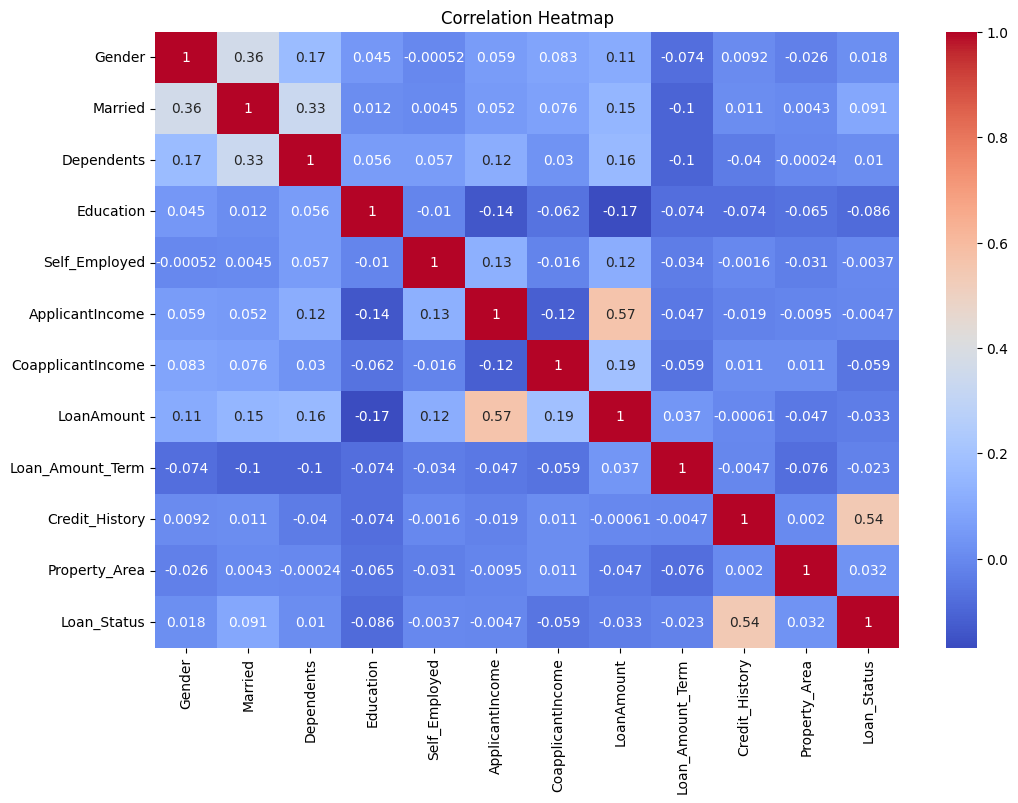

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Logistic Regression Accuracy = 0.7886178861788617
Decision Tree Accuracy = 0.6910569105691057
Random Forest Accuracy = 0.7560975609756098
{'max_depth': 5, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.90      0.42      0.57        43
           1       0.76      0.97      0.85        80

    accuracy                           0.78       123
   macro avg       0.83      0.70      0.71       123
weighted avg       0.81      0.78      0.75       123



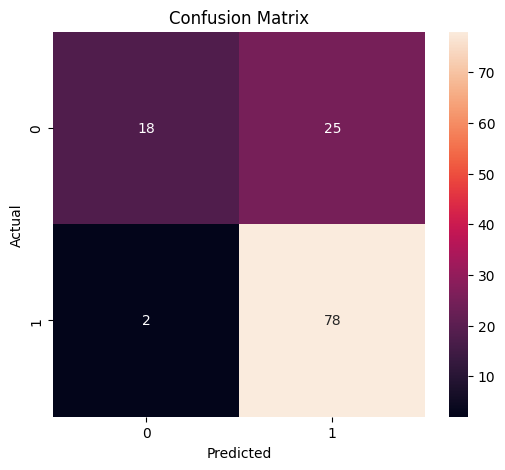

Loan Approved


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [1]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
dataset_path = "/content/drive/MyDrive/internship_csv_files/loan.csv"
df = pd.read_csv(dataset_path)

df.head()
print(df.shape)

df.info()

df.describe()
print(df.isnull().sum())
for col in df.columns:
    if df[col].dtype == 'object':
        df[col].fillna(df[col].mode()[0], inplace=True)
    else:
        df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())
df.drop('Loan_ID', axis=1, inplace=True)
le = LabelEncoder()

categorical_columns = [
    'Gender',
    'Married',
    'Dependents',
    'Education',
    'Self_Employed',
    'Property_Area',
    'Loan_Status'
]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()
plt.figure(figsize=(6,4))

sns.countplot(x='Loan_Status', data=df)

plt.title("Loan Status Distribution")

plt.show()
plt.figure(figsize=(6,4))

sns.countplot(
    x='Gender',
    hue='Loan_Status',
    data=df
)

plt.title("Gender vs Loan Status")

plt.show()
plt.figure(figsize=(6,4))

sns.countplot(
    x='Credit_History',
    hue='Loan_Status',
    data=df
)

plt.title("Credit History vs Loan Status")

plt.show()
plt.figure(figsize=(8,5))

sns.histplot(
    df['ApplicantIncome'],
    kde=True
)

plt.title("Applicant Income Distribution")

plt.show()
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()
X = df.drop('Loan_Status', axis=1)

y = df['Loan_Status']
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

lr_acc = accuracy_score(
    y_test,
    pred_lr
)

print("Logistic Regression Accuracy =", lr_acc)
dt = DecisionTreeClassifier(
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

dt_acc = accuracy_score(
    y_test,
    pred_dt
)

print("Decision Tree Accuracy =", dt_acc)
rf = RandomForestClassifier(
    random_state=42
)

rf.fit(X_train, y_train)

pred_rf = rf.predict(X_test)

rf_acc = accuracy_score(
    y_test,
    pred_rf
)

print("Random Forest Accuracy =", rf_acc)
comparison = pd.DataFrame({
    'Model':[
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    'Accuracy':[
        lr_acc,
        dt_acc,
        rf_acc
    ]
})

comparison
params = {
    'n_estimators':[50,100,200],
    'max_depth':[5,10,15]
}

grid = GridSearchCV(
    RandomForestClassifier(
        random_state=42
    ),
    params,
    cv=5
)

grid.fit(
    X_train,
    y_train
)

print(grid.best_params_)
best_model = grid.best_estimator_

pred = best_model.predict(
    X_test
)

print(
    classification_report(
        y_test,
        pred
    )
)
cm = confusion_matrix(
    y_test,
    pred
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()
sample = [[
    1,      # Gender
    1,      # Married
    0,      # Dependents
    0,      # Education
    0,      # Self Employed
    5000,   # ApplicantIncome
    2000,   # CoapplicantIncome
    150,    # LoanAmount
    360,    # Loan_Amount_Term
    1,      # Credit_History
    2       # Property_Area
]]

prediction = best_model.predict(sample)

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Rejected")